<a href="https://colab.research.google.com/github/AfnanSD/Arabic-Handwritten-Characters-Recognition/blob/main/Arbic_Letters_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The Goal

- Make nerual networks to recognize hand written Arabic letters
- dataset used: [Arabic Handwritten Characters Dataset](https://www.kaggle.com/datasets/mloey1/ahcd1/data)
  - 16,800 characters written by 60 participants
  - The age range is between 19 to 40 years
  - 90% of participants are right-hand
- picked model: [ViTB16](https://pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html) (The model picked based on the highest accuracy reached, which can be seen in the experiements section)
- deployed at HuggingFace and can be tried [here](https://huggingface.co/spaces/AfnanSD/Arabic-Handwritten-Characters-Recognition)

## Setup

In [ ]:
import torch
import torchvision

from torch import nn
from torchvision import transforms

import random
from tqdm.auto import tqdm
from typing import Dict, List, Tuple

try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

import matplotlib.pyplot as plt


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Helper Functions

In [ ]:
# Set seeds
def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:
    """Trains a PyTorch model for a single epoch.
    Turns a target PyTorch model to training mode and then
    runs through all of the required training steps (forward
    pass, loss calculation, optimizer step).
    Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").
    Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:
    (0.1112, 0.8743)
    """
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:
    """Tests a PyTorch model for a single epoch.
    Turns a target PyTorch model to "eval" mode and then performs
    a forward pass on a testing dataset.
    Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").
    Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:
    (0.0223, 0.8985)
    """
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [ ]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List]:
    """Trains and tests a PyTorch model.
    Passes a target PyTorch models through train_step() and test_step()
    functions for a number of epochs, training and testing the model
    in the same epoch loop.
    Calculates, prints and stores evaluation metrics throughout.
    Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").
    Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for
    each epoch.
    In the form: {train_loss: [...],
              train_acc: [...],
              test_loss: [...],
              test_acc: [...]}
    For example if training for epochs=2:
             {train_loss: [2.0616, 1.0537],
              train_acc: [0.3945, 0.3945],
              test_loss: [1.2641, 1.5706],
              test_acc: [0.3400, 0.2973]}
    """
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
    }

    # Make sure model on target device
    model.to(device)

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
        test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # Return the filled results at the end of the epochs
    return results

In [ ]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [ ]:
# Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
  # Adjust display if n too high
  if n > 10:
      n = 10
      display_shape = False
      print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

  # Set random seed
  if seed:
      random.seed(seed)

  # Get random sample indexes
  random_samples_idx = random.sample(range(len(dataset)), k=n)

  # Setup plot
  plt.figure(figsize=(16, 8))

  # Loop through samples and display random samples
  for i, targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    # Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
    targ_image_adjust = targ_image.permute(1, 2, 0)

    # Plot adjusted samples
    plt.subplot(1, n, i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("off")
    if classes:
      title = f"class: {classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape: {targ_image_adjust.shape}"
    plt.title(title)

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    # random.seed(seed)
    # random_image_paths = random.sample(image_paths, k=n)
    for image_path in image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            # transformed_image = transform(f)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            # fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

In [ ]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

In [ ]:
import torch
from pathlib import Path

def save_model(model: torch.nn.Module,
               target_dir: str,
               model_name: str):
    """Saves a PyTorch model to a target directory.

    Args:
    model: A target PyTorch model to save.
    target_dir: A directory for saving the model to.
    model_name: A filename for the saved model. Should include
      either ".pth" or ".pt" as the file extension.

    Example usage:
    save_model(model=model_0,
               target_dir="models",
               model_name="05_going_modular_tingvgg_model.pth")
    """
    # Create target directory
    target_dir_path = Path(target_dir)
    target_dir_path.mkdir(parents=True,
                        exist_ok=True)

    # Create model save path
    assert model_name.endswith(".pth") or model_name.endswith(".pt"), "model_name should end with '.pt' or '.pth'"
    model_save_path = target_dir_path / model_name

    # Save the model state_dict()
    print(f"[INFO] Saving model to: {model_save_path}")
    torch.save(obj=model.state_dict(),
             f=model_save_path)

## Getting Data

In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [ ]:
!kaggle datasets download -d mloey1/ahcd1

Dataset URL: https://www.kaggle.com/datasets/mloey1/ahcd1
License(s): DbCL-1.0
 50% 12.0M/24.0M [00:00<00:00, 61.0MB/s]
100% 24.0M/24.0M [00:00<00:00, 94.6MB/s]


In [ ]:
! mkdir data

In [ ]:
! unzip ahcd1.zip -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/train images 13440x32x32/train/id_5500_label_16.png  
  inflating: data/train images 13440x32x32/train/id_5501_label_16.png  
  inflating: data/train images 13440x32x32/train/id_5502_label_16.png  
  inflating: data/train images 13440x32x32/train/id_5503_label_16.png  
  inflating: data/train images 13440x32x32/train/id_5504_label_16.png  
  inflating: data/train images 13440x32x32/train/id_5505_label_17.png  
  inflating: data/train images 13440x32x32/train/id_5506_label_17.png  
  inflating: data/train images 13440x32x32/train/id_5507_label_17.png  
  inflating: data/train images 13440x32x32/train/id_5508_label_17.png  
  inflating: data/train images 13440x32x32/train/id_5509_label_17.png  
  inflating: data/train images 13440x32x32/train/id_550_label_13.png  
  inflating: data/train images 13440x32x32/train/id_5510_label_17.png  
  inflating: data/train images 13440x32x32/train/id_5511_label_17.png  
  inflating: d

## Exploring The Data

In [ ]:
%%bash
cd data
ls

arabic handwritten characters dataset csv
Arabic Handwritten Characters Dataset CSV
csvTestImages 3360x1024.csv
csvTestLabel 3360x1.csv
csvTrainImages 13440x1024.csv
csvTrainLabel 13440x1.csv
test images 3360x32x32
Test Images 3360x32x32
train images 13440x32x32
Train Images 13440x32x32
Train+Test Images Matlab.mat


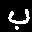

In [ ]:
from PIL import Image

img = Image.open("data/train images 13440x32x32/train/id_9_label_2.png")
img

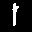

In [ ]:
img = Image.open("data/train images 13440x32x32/train/id_9633_label_1.png")
img

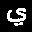

In [ ]:
img = Image.open("data/train images 13440x32x32/train/id_9632_label_28.png")
img

In [ ]:
!cd "data/test images 3360x32x32/test" && ls

id_1000_label_24.png  id_1758_label_11.png  id_2513_label_25.png  id_326_label_23.png
id_1001_label_25.png  id_1759_label_12.png  id_2514_label_25.png  id_3270_label_11.png
id_1002_label_25.png  id_175_label_4.png    id_2515_label_26.png  id_3271_label_12.png
id_1003_label_26.png  id_1760_label_12.png  id_2516_label_26.png  id_3272_label_12.png
id_1004_label_26.png  id_1761_label_13.png  id_2517_label_27.png  id_3273_label_13.png
id_1005_label_27.png  id_1762_label_13.png  id_2518_label_27.png  id_3274_label_13.png
id_1006_label_27.png  id_1763_label_14.png  id_2519_label_28.png  id_3275_label_14.png
id_1007_label_28.png  id_1764_label_14.png  id_251_label_14.png   id_3276_label_14.png
id_1008_label_28.png  id_1765_label_15.png  id_2520_label_28.png  id_3277_label_15.png
id_1009_label_1.png   id_1766_label_15.png  id_2521_label_1.png   id_3278_label_15.png
id_100_label_22.png   id_1767_label_16.png  id_2522_label_1.png   id_3279_label_16.png
id_1010_label_1.png   id_1768_label_16.png  

In [ ]:
!cd "data/Test Images 3360x32x32/test" && ls

id_1000_label_24.png  id_1758_label_11.png  id_2513_label_25.png  id_326_label_23.png
id_1001_label_25.png  id_1759_label_12.png  id_2514_label_25.png  id_3270_label_11.png
id_1002_label_25.png  id_175_label_4.png    id_2515_label_26.png  id_3271_label_12.png
id_1003_label_26.png  id_1760_label_12.png  id_2516_label_26.png  id_3272_label_12.png
id_1004_label_26.png  id_1761_label_13.png  id_2517_label_27.png  id_3273_label_13.png
id_1005_label_27.png  id_1762_label_13.png  id_2518_label_27.png  id_3274_label_13.png
id_1006_label_27.png  id_1763_label_14.png  id_2519_label_28.png  id_3275_label_14.png
id_1007_label_28.png  id_1764_label_14.png  id_251_label_14.png   id_3276_label_14.png
id_1008_label_28.png  id_1765_label_15.png  id_2520_label_28.png  id_3277_label_15.png
id_1009_label_1.png   id_1766_label_15.png  id_2521_label_1.png   id_3278_label_15.png
id_100_label_22.png   id_1767_label_16.png  id_2522_label_1.png   id_3279_label_16.png
id_1010_label_1.png   id_1768_label_16.png  

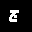

In [ ]:
img = Image.open("data/Test Images 3360x32x32/test/id_1689_label_5.png")
img

- letters ranged from "X_1" = "أ" to "X_28" = "ي"

In [ ]:
!cd "data/test images 3360x32x32/test" && ls | wc -l

3360


In [ ]:
!cd "data/Test Images 3360x32x32/test" && ls | wc -l

3360


In [ ]:
!cd "data/Train Images 13440x32x32/train" && ls | wc -l

13440


In [ ]:
!cd "data/train images 13440x32x32/train" && ls | wc -l

13440


In [ ]:
13440 + 3360

16800

- there are 16800 imgaes
  - train images = 13440
  - test images = 3360

In [ ]:
walk_through_dir("data/")

There are 6 directories and 5 images in 'data/'.
There are 1 directories and 0 images in 'data/test images 3360x32x32'.
There are 0 directories and 3360 images in 'data/test images 3360x32x32/test'.
There are 0 directories and 4 images in 'data/Arabic Handwritten Characters Dataset CSV'.
There are 1 directories and 0 images in 'data/Train Images 13440x32x32'.
There are 0 directories and 13440 images in 'data/Train Images 13440x32x32/train'.
There are 1 directories and 0 images in 'data/train images 13440x32x32'.
There are 0 directories and 13440 images in 'data/train images 13440x32x32/train'.
There are 0 directories and 4 images in 'data/arabic handwritten characters dataset csv'.
There are 1 directories and 0 images in 'data/Test Images 3360x32x32'.
There are 0 directories and 3360 images in 'data/Test Images 3360x32x32/test'.


- images appeared to be duplicated in
  - 'data/Test Images 3360x32x32/test'
  - data/test images 3360x32x32/test'
  - **and**
  - 'data/Train Images 13440x32x32/train'
  - 'data/train images 13440x32x32/train'

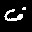

In [ ]:
img = Image.open("data/Test Images 3360x32x32/test/id_3231_label_20.png")
img

In [ ]:
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")

Image height: 32
Image width: 32


In [ ]:
img.filename

'data/Test Images 3360x32x32/test/id_3231_label_20.png'

In [ ]:
img.filename[-5]

'0'

In [ ]:
start = img.filename.rindex('_')
start

46

In [ ]:
end = img.filename.rindex('.')
end

49

In [ ]:
img.filename[start+1:end]

'20'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

img_as_array.shape

(32, 32)

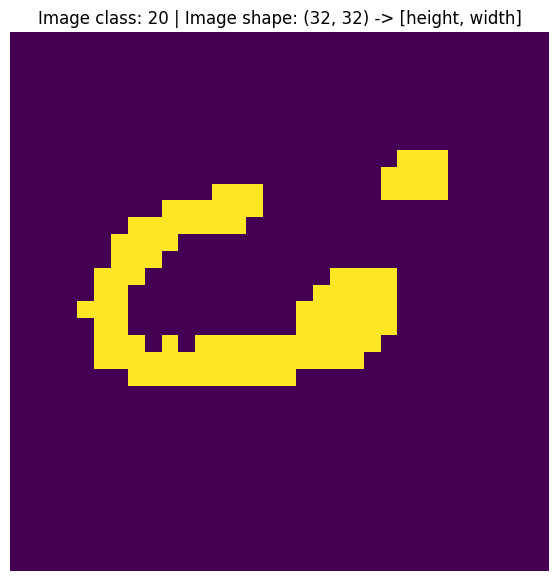

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

start = img.filename.rindex('_')
end = img.filename.rindex('.')
image_class = img.filename[start+1:end]

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width]")
plt.axis(False);

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
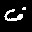

In [ ]:
img_as_array

In [ ]:
img_as_array.argmin() , img_as_array.argmax()

(0, 247)

- image shape is [32, 32] = [height, width]
- image has only one color channel = grey

## Transforming The Data

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
# Write transform for image
data_transform = transforms.Compose([
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0
])

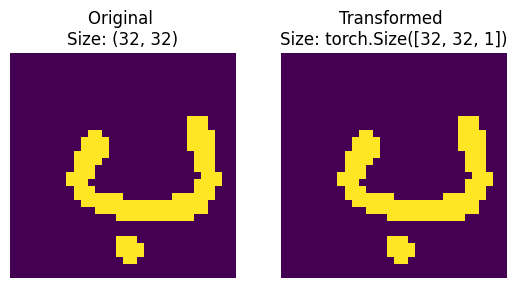

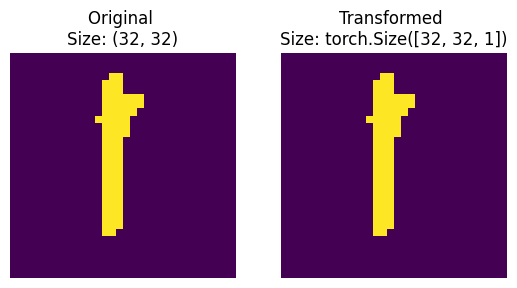

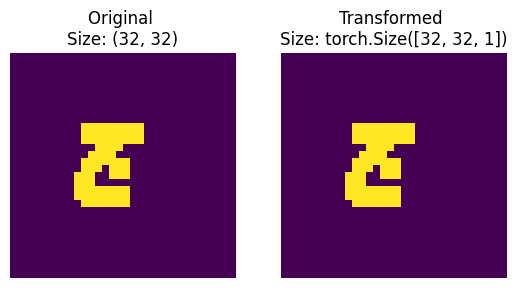

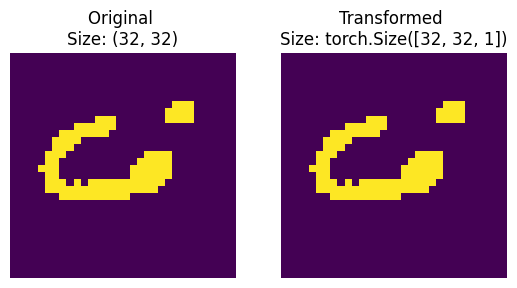

In [ ]:
plot_transformed_images(["data/train images 13440x32x32/train/id_9_label_2.png",
                         "data/train images 13440x32x32/train/id_9633_label_1.png",
                         "data/Test Images 3360x32x32/test/id_1689_label_5.png",
                         "data/Test Images 3360x32x32/test/id_3231_label_20.png"],
                        transform=data_transform,
                        n=3)

## Build Custom Dataset

In [ ]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [ ]:
# Build dictonary clases  manually
class_to_idx = {
    1:'أ',
    2:'ب',
    3:'ت',
    4:'ث',
    5:'ج',
    6:'ح',
    7:'خ',
    8:'د',
    9:'ذ',
    10:'ر',
    11:'ز',
    12:'س',
    13:'ش',
    14:'ص',
    15:'ض',
    16:'ط',
    17:'ظ',
    18:'ع',
    19:'غ',
    20:'ف',
    21:'ق',
    22:'ك',
    23:'ل',
    24:'م',
    25:'ن',
    26:'ه',
    27:'و',
    28:'ي',
}

In [ ]:
class_to_idx[20]

'ف'

In [ ]:
classes = ['أ','ب','ت','ث','ج','ح','خ','د','ذ','ر','ز','س','ش','ص','ض','ط','ظ','ع','غ','ف','ق','ك','ل','م','ن','ه','و','ي']

In [ ]:
# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

# Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # Initialize with a targ_dir and transform (optional) parameter
  def __init__(self, classes, class_to_idx, targ_dir: str, transform=None) -> None:
    # Create class attributes
    # Get all image paths
    self.paths = list(pathlib.Path(targ_dir).glob("*"))
    # Setup transforms
    self.transform = transform
    # Setup classes and class_to_idx attributes
    self.classes, self.class_to_idx = classes, class_to_idx

  # Make function to load images
  def load_image(self, index: int) -> Image.Image:
    "Opens an image via a path and returns it."
    image_path = self.paths[index]
    return Image.open(image_path)

  # Overwrite the __len__() method
  def __len__(self) -> int:
    "Returns the total number of samples."
    return len(self.paths)

  # Overwrite the __getitem__() method
  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
    "Returns one sample of data, data and label (X, y)."
    img = self.load_image(index)
    # class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
    # class_idx = self.class_to_idx[class_name]
    start = img.filename.rindex('_')
    end = img.filename.rindex('.')
    class_idx = int(img.filename[start+1:end]) - 1


    # Transform if necessary
    if self.transform:
        return self.transform(img), class_idx # return data, label (X, y)
    else:
        return img, class_idx # return data, label (X, y)

In [ ]:
# Write transform for image
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
train_dir = "data/Train Images 13440x32x32/train"
test_dir = "data/Test Images 3360x32x32/test"

In [ ]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms,
                                      classes=classes,
                                      class_to_idx=class_to_idx)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms,
                                     classes=classes,
                                     class_to_idx=class_to_idx)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7fe8cc50c190>,
 <__main__.ImageFolderCustom at 0x7fe8cc4fbc50>)

In [ ]:
train_data_custom.class_to_idx

{1: 'أ',
 2: 'ب',
 3: 'ت',
 4: 'ث',
 5: 'ج',
 6: 'ح',
 7: 'خ',
 8: 'د',
 9: 'ذ',
 10: 'ر',
 11: 'ز',
 12: 'س',
 13: 'ش',
 14: 'ص',
 15: 'ض',
 16: 'ط',
 17: 'ظ',
 18: 'ع',
 19: 'غ',
 20: 'ف',
 21: 'ق',
 22: 'ك',
 23: 'ل',
 24: 'م',
 25: 'ن',
 26: 'ه',
 27: 'و',
 28: 'ي'}

In [ ]:
train_data_custom.classes

['أ',
 'ب',
 'ت',
 'ث',
 'ج',
 'ح',
 'خ',
 'د',
 'ذ',
 'ر',
 'ز',
 'س',
 'ش',
 'ص',
 'ض',
 'ط',
 'ظ',
 'ع',
 'غ',
 'ف',
 'ق',
 'ك',
 'ل',
 'م',
 'ن',
 'ه',
 'و',
 'ي']

In [ ]:
len(train_data_custom), len(test_data_custom)

(13440, 3360)

In [ ]:
targ_image, targ_label = train_data_custom[0][0], train_data_custom[0][1]
targ_image, targ_label

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 22)

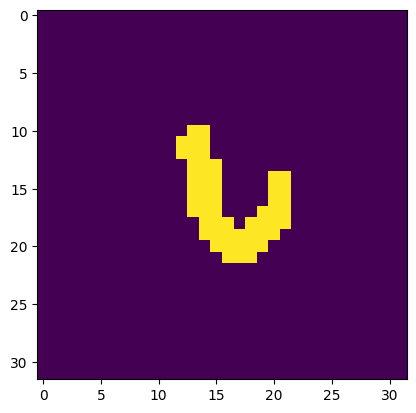

In [ ]:
targ_image_adjust = targ_image.permute(1, 2, 0)
plt.imshow(targ_image_adjust)

In [ ]:
classes[int(targ_label)]

'ل'

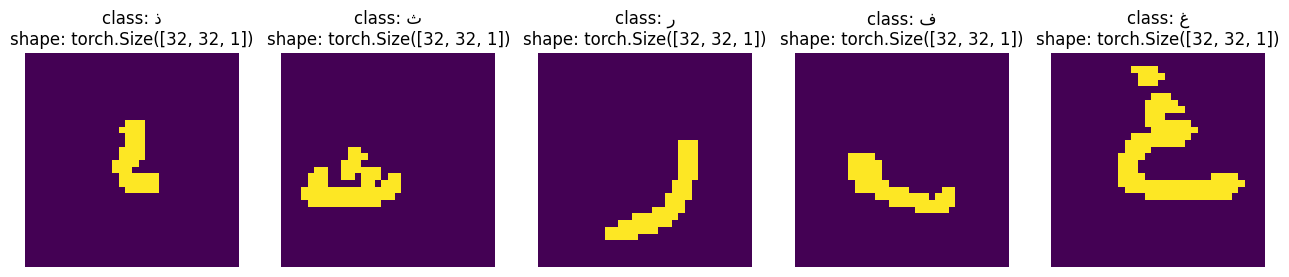

In [ ]:
# Display random images from ImageFolder created Dataset
display_random_images(train_data_custom,
                      n=5,
                      classes=classes,
                      seed=None)

## Create Dataloaders

In [ ]:
# Turn train and test custom Dataset's into DataLoader's
from torch.utils.data import DataLoader

train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=32,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=32,
                                    shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7fe8c9cc6110>,
 <torch.utils.data.dataloader.DataLoader at 0x7fe8ca0094d0>)

In [ ]:
# Get image and label from custom DataLoader
img_custom, label_custom = next(iter(train_dataloader_custom))

print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([32, 1, 32, 32]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


## Train The Models
- Use transfer learning, try different models to find the best preforming one based on accuracy
- models to try
  - EfficientNetB0
  - EfficientNetB2
  - ViTB16

### EfficientNetB0

#### Setup Dataloaders

In [ ]:
# Setup pretrained weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT


# Get transforms from weights
efficientNet_b0_transforms = weights.transforms()


# Extend the efficientNet_b0_transforms to include grayscale conversion, since EfficientNet_B0 is trained on 3-channel RGB
extended_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel RGB
    efficientNet_b0_transforms  # Append the existing transforms
])

# Create datasets
efficientNet_b0_train_data = ImageFolderCustom(targ_dir=train_dir,
                                      transform=extended_transform,
                                      classes=classes,
                                      class_to_idx=class_to_idx)

efficientNet_b0_test_data = ImageFolderCustom(targ_dir=test_dir,
                                     transform=extended_transform,
                                     classes=classes,
                                     class_to_idx=class_to_idx)


# Create data loaders
efficientNet_b0_train_dataloader = DataLoader(dataset=efficientNet_b0_train_data,
                                     batch_size=32,
                                     shuffle=True)

efficientNet_b0_test_dataloader = DataLoader(dataset=efficientNet_b0_test_data,
                                    batch_size=32,
                                    shuffle=False)

#### Setup The Model

In [ ]:
# Setup the model with the pretrained weights and send it to the target device
efficientNet_b0_model = torchvision.models.efficientnet_b0(weights=weights).to(device)
efficientNet_b0_model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Freeze all base layers by setting requires_grad attribute to False
for param in efficientNet_b0_model.features.parameters():
  param.requires_grad = False

set_seeds()

# Update the classifier head
efficientNet_b0_model.classifier = torch.nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280,
              out_features=28, # Number of Arabic letters = our classes
              bias=True).to(device))

efficientNet_b0_model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
from torchinfo import summary

# Get a summary of the model
summary(efficientNet_b0_model,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 28]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

#### Train The Model and Track Results

In [ ]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(efficientNet_b0_model.parameters(), lr=0.001)

In [ ]:
# Train model
set_seeds()
efficientNet_b0_results = train(model=efficientNet_b0_model,
                train_dataloader=efficientNet_b0_train_dataloader,
                test_dataloader=efficientNet_b0_test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=5,
                device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.7695 | train_acc: 0.5591 | test_loss: 0.9391 | test_acc: 0.7491
Epoch: 2 | train_loss: 1.0868 | train_acc: 0.7045 | test_loss: 0.7256 | test_acc: 0.7935
Epoch: 3 | train_loss: 0.9237 | train_acc: 0.7393 | test_loss: 0.6514 | test_acc: 0.8033
Epoch: 4 | train_loss: 0.8369 | train_acc: 0.7541 | test_loss: 0.5898 | test_acc: 0.8247
Epoch: 5 | train_loss: 0.7839 | train_acc: 0.7688 | test_loss: 0.5744 | test_acc: 0.8226


In [ ]:
efficientNet_b0_results

{'train_loss': [1.7695342441399893,
  1.086787004981722,
  0.9236826957691283,
  0.8369148824186552,
  0.7838801185999598],
 'train_acc': [0.5590773809523809,
  0.7044642857142858,
  0.7392857142857143,
  0.7540922619047619,
  0.76875],
 'test_loss': [0.9390914093880426,
  0.7255825593357994,
  0.6514071004731314,
  0.5898253639539083,
  0.5743761579195659],
 'test_acc': [0.7491071428571429,
  0.7934523809523809,
  0.8032738095238096,
  0.8247023809523809,
  0.8226190476190476]}

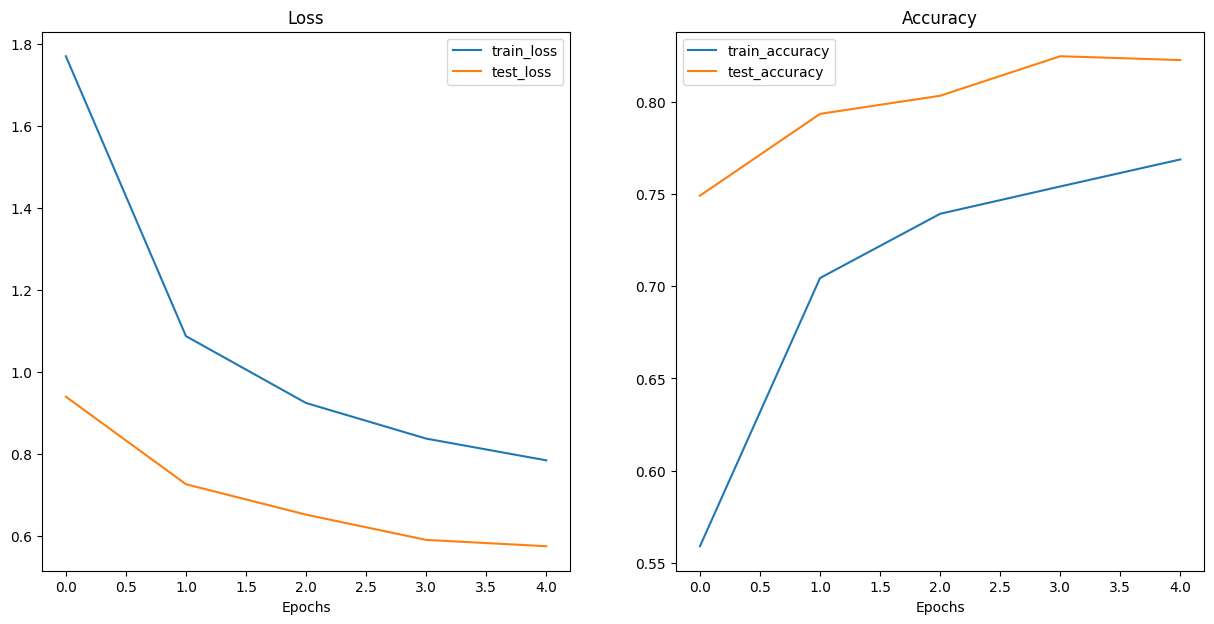

In [ ]:
plot_loss_curves(efficientNet_b0_results)

In [ ]:
import pandas as pd

efficientNet_b0_df = pd.DataFrame(efficientNet_b0_results)
efficientNet_b0_df.head()

,train_loss,train_acc,test_loss,test_acc
0,1.769534,0.559077,0.939091,0.749107
1,1.086787,0.704464,0.725583,0.793452
2,0.923683,0.739286,0.651407,0.803274
3,0.836915,0.754092,0.589825,0.824702
4,0.783880,0.768750,0.574376,0.822619


In [ ]:
# Save the model
save_model(model=efficientNet_b0_model,
                 target_dir="models",
                 model_name="efficientNet_b0_model.pth")

[INFO] Saving model to: models/efficientNet_b0_model.pth


### EfficientNetB2

#### Setup Dataloaders

In [ ]:
# Setup pretrained weights
weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT


# Get transforms from weights
efficientNet_b2_transforms = weights.transforms()


# Extend the efficientNet_b2_transforms to include grayscale conversion, since EfficientNet_B2 is trained on 3-channel RGB
extended_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel RGB
    efficientNet_b2_transforms  # Append the existing transforms
])

# Create datasets
efficientNet_b2_train_data = ImageFolderCustom(targ_dir=train_dir,
                                      transform=extended_transform,
                                      classes=classes,
                                      class_to_idx=class_to_idx)

efficientNet_b2_test_data = ImageFolderCustom(targ_dir=test_dir,
                                     transform=extended_transform,
                                     classes=classes,
                                     class_to_idx=class_to_idx)


# Create data loaders
efficientNet_b2_train_dataloader = DataLoader(dataset=efficientNet_b2_train_data,
                                     batch_size=32,
                                     shuffle=True)

efficientNet_b2_test_dataloader = DataLoader(dataset=efficientNet_b2_test_data,
                                    batch_size=32,
                                    shuffle=False)

#### Setup The Model

In [ ]:
# Setup the model with the pretrained weights and send it to the target device
efficientNet_b2_model = torchvision.models.efficientnet_b2(weights=weights).to(device)
efficientNet_b2_model

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 116MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Freeze all base layers by setting requires_grad attribute to False
for param in efficientNet_b2_model.features.parameters():
  param.requires_grad = False

set_seeds()

# Update the classifier head
efficientNet_b2_model.classifier = torch.nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1408,
              out_features=28, # Number of Arabic letters = our classes
              bias=True).to(device))

efficientNet_b2_model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
from torchinfo import summary

# Get a summary of the model
summary(efficientNet_b2_model,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 28]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1408, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

#### Train The Model and Track Results

In [ ]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(efficientNet_b2_model.parameters(), lr=0.001)

In [ ]:
# Train model
set_seeds()
efficientNet_b2_results = train(model=efficientNet_b2_model,
                train_dataloader=efficientNet_b2_train_dataloader,
                test_dataloader=efficientNet_b2_test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=5,
                device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.8607 | train_acc: 0.5480 | test_loss: 1.0520 | test_acc: 0.7327
Epoch: 2 | train_loss: 1.1352 | train_acc: 0.6972 | test_loss: 0.8049 | test_acc: 0.7786
Epoch: 3 | train_loss: 0.9746 | train_acc: 0.7214 | test_loss: 0.7149 | test_acc: 0.7955
Epoch: 4 | train_loss: 0.8861 | train_acc: 0.7406 | test_loss: 0.6612 | test_acc: 0.8057
Epoch: 5 | train_loss: 0.8275 | train_acc: 0.7584 | test_loss: 0.6235 | test_acc: 0.8125


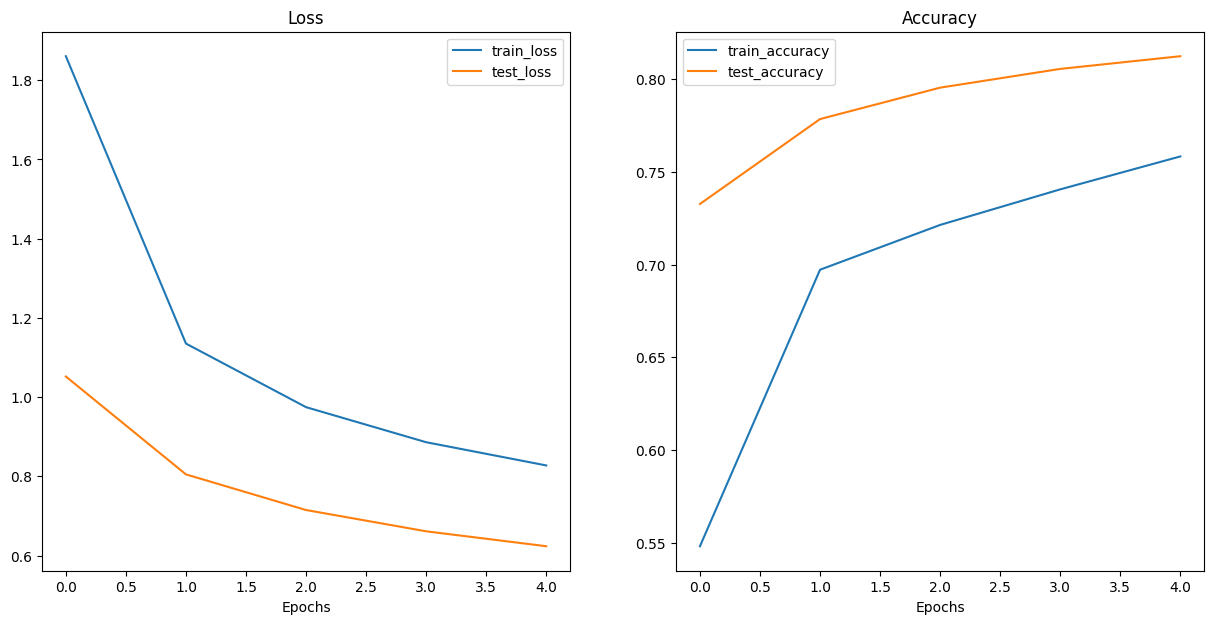

In [ ]:
plot_loss_curves(efficientNet_b2_results)

In [ ]:
import pandas as pd

efficientNet_b2_df = pd.DataFrame(efficientNet_b2_results)
efficientNet_b2_df.head()

,train_loss,train_acc,test_loss,test_acc
0,1.860704,0.547991,1.052006,0.732738
1,1.135181,0.697247,0.804876,0.778571
2,0.974625,0.721429,0.714947,0.795536
3,0.886146,0.740625,0.661203,0.805655
4,0.827524,0.758408,0.623535,0.812500


In [ ]:
# Save the model
save_model(model=efficientNet_b2_model,
                 target_dir="models",
                 model_name="efficientNet_b2_model.pth")

[INFO] Saving model to: models/efficientNet_b2_model.pth


### ViTB16

#### Setup Dataloaders

In [ ]:
# Setup pretrained weights
weights = torchvision.models.ViT_B_16_Weights.DEFAULT


# Get transforms from weights
vit_transforms = weights.transforms()


# Extend the vit_transforms to include grayscale conversion, since vit is trained on 3-channel RGB
extended_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel RGB
    vit_transforms  # Append the existing transforms
])

# Create datasets
vit_train_data = ImageFolderCustom(targ_dir=train_dir,
                                      transform=extended_transform,
                                      classes=classes,
                                      class_to_idx=class_to_idx)

vit_test_data = ImageFolderCustom(targ_dir=test_dir,
                                     transform=extended_transform,
                                     classes=classes,
                                     class_to_idx=class_to_idx)


# Create data loaders
vit_train_dataloader = DataLoader(dataset=vit_train_data,
                                     batch_size=32,
                                     shuffle=True)

vit_test_dataloader = DataLoader(dataset=vit_test_data,
                                    batch_size=32,
                                    shuffle=False)

#### Setup The Model

In [ ]:
# Setup the model with the pretrained weights and send it to the target device
vit_model = torchvision.models.vit_b_16(weights=weights).to(device)
vit_model

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:07<00:00, 48.0MB/s]


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
# Freeze all base layers by setting requires_grad attribute to False
for param in vit_model.parameters():
  param.requires_grad = False

set_seeds()

# Update the classifier head
vit_model.heads = torch.nn.Sequential(
    nn.Linear(in_features=768,
              out_features=28, # Number of Arabic letters = our classes
              bias=True).to(device))

vit_model

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
from torchinfo import summary

# Get a summary of the model
summary(vit_model,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 28]             768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              False
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [32, 

#### Train The Model and Track Results

In [ ]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vit_model.parameters(), lr=0.001)

In [ ]:
# Train model
set_seeds()
vit_results = train(model=vit_model,
                train_dataloader=vit_train_dataloader,
                test_dataloader=vit_test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=5,
                device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.2255 | train_acc: 0.6770 | test_loss: 0.9352 | test_acc: 0.7604
Epoch: 2 | train_loss: 0.8467 | train_acc: 0.7684 | test_loss: 0.7418 | test_acc: 0.7952
Epoch: 3 | train_loss: 0.7031 | train_acc: 0.8029 | test_loss: 0.6796 | test_acc: 0.8057
Epoch: 4 | train_loss: 0.6232 | train_acc: 0.8246 | test_loss: 0.6109 | test_acc: 0.8307
Epoch: 5 | train_loss: 0.5640 | train_acc: 0.8398 | test_loss: 0.5735 | test_acc: 0.8375


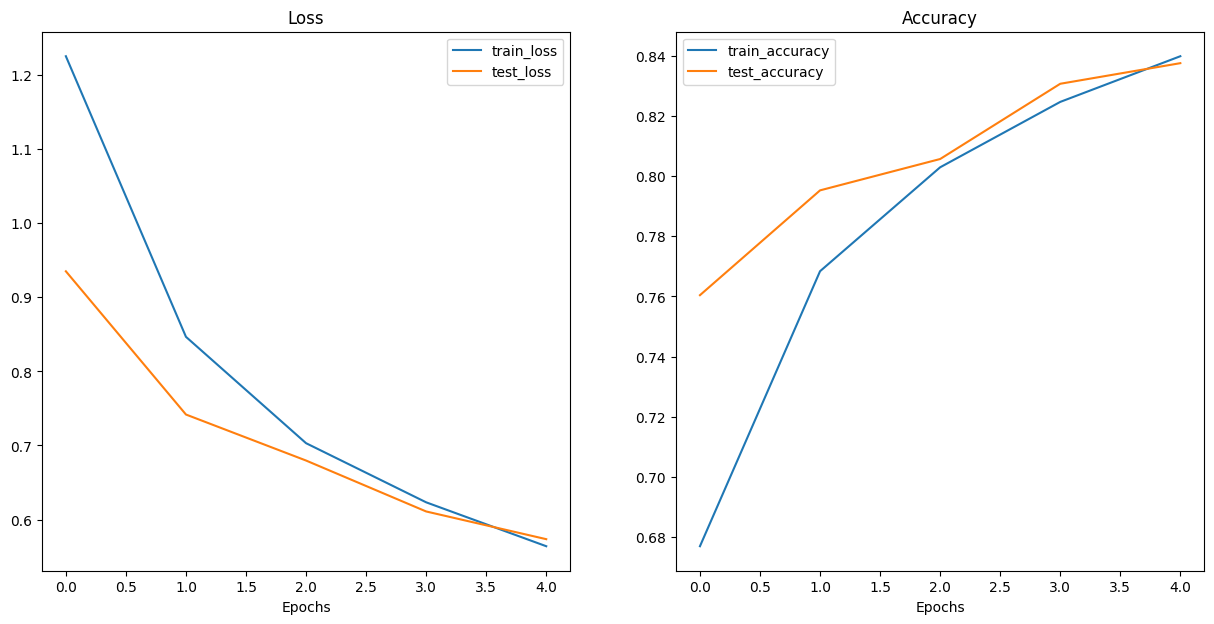

In [ ]:
plot_loss_curves(vit_results)

In [ ]:
import pandas as pd

vit_df = pd.DataFrame(vit_results)
vit_df.head()

,train_loss,train_acc,test_loss,test_acc
0,1.225530,0.677009,0.935158,0.760417
1,0.846665,0.768378,0.741763,0.795238
2,0.703071,0.802902,0.679646,0.805655
3,0.623232,0.824628,0.610884,0.830655
4,0.563953,0.839807,0.573474,0.837500


In [ ]:
# Save the model
save_model(model=vit_model,
                 target_dir="models",
                 model_name="vit_model.pth")

[INFO] Saving model to: models/vit_model.pth


### Compare Models' Results

In [ ]:
# Count number of parameters in EffNetB0
effnetb0_total_params = sum(torch.numel(param) for param in efficientNet_b0_model.parameters())
effnetb0_total_params

4043416

In [ ]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in efficientNet_b2_model.parameters())
effnetb2_total_params

7740446

In [ ]:
# Count number of parameters in ViTB16
vit_total_params = sum(torch.numel(param) for param in vit_model.parameters())
vit_total_params

85820188

In [ ]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_effnetb0_model_size = Path("models/efficientNet_b0_model.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly)
print(f"Pretrained EffNetB0 feature extractor model size: {pretrained_effnetb0_model_size} MB")

Pretrained EffNetB0 feature extractor model size: 15 MB


In [ ]:
# Get the model size in bytes then convert to megabytes
pretrained_effnetb2_model_size = Path("models/efficientNet_b2_model.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly)
print(f"Pretrained EffNetB2 feature extractor model size: {pretrained_effnetb2_model_size} MB")

Pretrained EffNetB2 feature extractor model size: 29 MB


In [ ]:
# Get the model size in bytes then convert to megabytes
pretrained_vit_model_size = Path("models/vit_model.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly)
print(f"Pretrained ViTB16 feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViTB16 feature extractor model size: 327 MB


In [ ]:
# Create a dictionary with EffNetB0 statistics
effnetb0_stats = {"test_loss": efficientNet_b0_results["test_loss"][-1],
                  "test_acc": efficientNet_b0_results["test_acc"][-1],
                  "number_of_parameters": effnetb0_total_params,
                  "model_size (MB)": pretrained_effnetb0_model_size}
effnetb0_stats

{'test_loss': 0.5743761579195659,
 'test_acc': 0.8226190476190476,
 'number_of_parameters': 4043416,
 'model_size (MB)': 15}

In [ ]:
# Create a dictionary with EffNetB2 statistics
effnetb2_stats = {"test_loss": efficientNet_b2_results["test_loss"][-1],
                  "test_acc": efficientNet_b2_results["test_acc"][-1],
                  "number_of_parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.623535,
 'test_acc': 0.8125,
 'number_of_parameters': 7740446,
 'model_size (MB)': 29}

In [ ]:
# Create a dictionary with ViT statistics
vit_stats = {"test_loss": vit_results["test_loss"][-1],
                  "test_acc": vit_results["test_acc"][-1],
                  "number_of_parameters": vit_total_params,
                  "model_size (MB)": pretrained_vit_model_size}
vit_stats

{'test_loss': 0.573474,
 'test_acc': 0.8375,
 'number_of_parameters': 85820188,
 'model_size (MB)': 327}

In [ ]:
# Turn stat dictionaries into DataFrame
df = pd.DataFrame([effnetb0_stats, effnetb2_stats, vit_stats])

# Add column for model names
df["model"] = ["EffNetB0", "EffNetB2", "ViT"]

# Convert accuracy to percentages
df["test_acc"] = round(df["test_acc"] * 100, 2)

df

,test_loss,test_acc,number_of_parameters,model_size (MB),model
0,0.574376,82.26,4043416,15,EffNetB0
1,0.623535,81.25,7740446,29,EffNetB2
2,0.573474,83.75,85820188,327,ViT


- The best model based on accuracy is **ViTB16** with **83.75%**

## Deploying The Model

### Building Gradio App

In [ ]:
# Import/install Gradio
try:
    import gradio as gr
except:
    !pip -q install gradio
    import gradio as gr

print(f"Gradio version: {gr.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.9/321.9 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 whic

In [ ]:
from typing import Tuple, Dict
from timeit import default_timer as timer

def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()

    # Transform the target image and add a batch dimension
    img = extended_transform(img).unsqueeze(0)

    # Put model into evaluation mode and turn on inference mode
    vit.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(vit(img), dim=1)

    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {classes[i]: float(pred_probs[0][i]) for i in range(len(classes))}

    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)

    # Return the prediction dictionary and prediction time
    return pred_labels_and_probs, pred_time

In [ ]:
import random
from PIL import Image

# Select a test image path
random_image_path = 'data/Test Images 3360x32x32/test/id_3231_label_20.png'

# Open the target image
image = Image.open(random_image_path)
print(f"[INFO] Predicting on image at path: {random_image_path}\n")

# Predict on the target image and print out the outputs
pred_dict, pred_time = predict(img=image)
print(f"Prediction label and probability dictionary: \n{pred_dict}")
print(f"Prediction time: {pred_time} seconds")

[INFO] Predicting on image at path: data/Test Images 3360x32x32/test/id_3231_label_20.png

Prediction label and probability dictionary: 
{'أ': 1.9981123841716908e-05, 'ب': 0.005211970303207636, 'ت': 0.20055145025253296, 'ث': 0.021025020629167557, 'ج': 0.08548767119646072, 'ح': 0.05015337094664574, 'خ': 0.00784791074693203, 'د': 0.006035457830876112, 'ذ': 0.08495040237903595, 'ر': 0.00023826926189940423, 'ز': 0.003863107180222869, 'س': 0.002778904978185892, 'ش': 0.005830370355397463, 'ص': 0.0023426427505910397, 'ض': 0.038533568382263184, 'ط': 0.00011061602708650753, 'ظ': 0.0007633947534486651, 'ع': 0.014319092966616154, 'غ': 0.0019298007246106863, 'ف': 0.30388185381889343, 'ق': 0.06403971463441849, 'ك': 0.0018271910957992077, 'ل': 4.340598388807848e-05, 'م': 0.0007293428061529994, 'ن': 0.006851221900433302, 'ه': 0.0014414364704862237, 'و': 0.0014801135985180736, 'ي': 0.08771269768476486}
Prediction time: 1.06537 seconds


In [ ]:
# Manually reate a list of example inputs to our Gradio demo
example_list = ["data/train images 13440x32x32/train/id_9_label_2.png",
                "data/train images 13440x32x32/train/id_9633_label_1.png",
                "data/Test Images 3360x32x32/test/id_1689_label_5.png",
                "data/Test Images 3360x32x32/test/id_3231_label_20.png",
                "data/Test Images 3360x32x32/test/id_1099_label_18.png"]
example_list

['data/train images 13440x32x32/train/id_9_label_2.png',
 'data/train images 13440x32x32/train/id_9633_label_1.png',
 'data/Test Images 3360x32x32/test/id_1689_label_5.png',
 'data/Test Images 3360x32x32/test/id_3231_label_20.png',
 'data/Test Images 3360x32x32/test/id_1099_label_18.png']

In [ ]:
import gradio as gr

# Create title, description and article strings
title = "Arabic Handwritten Characters Recognition"
description = "A ViTB16 feature extractor computer vision model to classify hand written Arabic letters."

# Create the Gradio demo
demo = gr.Interface(fn=predict, # mapping function from input to output
                    inputs=gr.Image(type="pil"),
                    outputs=[gr.Label(num_top_classes=38, label="Predictions"),
                             gr.Number(label="Prediction time (s)")],
                    examples=example_list,
                    title=title,
                    description=description)

# Launch the demo!
demo.launch(debug=False,
            share=True) # generate a publically shareable URL

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9e72043e45c620683a.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Deploying on Hugging Face

In [ ]:
import shutil
from pathlib import Path

# Createi demo path
demo_path = Path("demos/arabic-handwritten-characters-recongintion/")

# Remove files that might already exist there and create new directory
if demo_path.exists():
    shutil.rmtree(demo_path)
# If the file doesn't exist, create it anyway
demo_path.mkdir(parents=True,
                                exist_ok=True)

# Check what's in the folder
!ls demos/arabic-handwritten-characters-recongintion/

In [ ]:
import shutil
from pathlib import Path

# Create an examples directory
examples_path = demo_path / "examples"
examples_path.mkdir(parents=True, exist_ok=True)

# Collect image paths
examples = [Path('data/train images 13440x32x32/train/id_9_label_2.png'),
            Path('data/train images 13440x32x32/train/id_9633_label_1.png'),
            Path('data/Test Images 3360x32x32/test/id_1689_label_5.png'),
            Path('data/Test Images 3360x32x32/test/id_3231_label_20.png'),
            Path("data/Test Images 3360x32x32/test/id_1099_label_18.png")]

# Copy the images to the examples directory
for example in examples:
    destination = examples_path / example.name
    print(f"[INFO] Copying {example} to {destination}")
    shutil.copy2(src=example, dst=destination)

[INFO] Copying data/train images 13440x32x32/train/id_9_label_2.png to demos/arabic-handwritten-characters-recongintion/examples/id_9_label_2.png
[INFO] Copying data/train images 13440x32x32/train/id_9633_label_1.png to demos/arabic-handwritten-characters-recongintion/examples/id_9633_label_1.png
[INFO] Copying data/Test Images 3360x32x32/test/id_1689_label_5.png to demos/arabic-handwritten-characters-recongintion/examples/id_1689_label_5.png
[INFO] Copying data/Test Images 3360x32x32/test/id_3231_label_20.png to demos/arabic-handwritten-characters-recongintion/examples/id_3231_label_20.png
[INFO] Copying data/Test Images 3360x32x32/test/id_1099_label_18.png to demos/arabic-handwritten-characters-recongintion/examples/id_1099_label_18.png


In [ ]:
import os

# Get example filepaths in a list of lists
example_list = [["examples/" + example] for example in os.listdir(examples_path)]
example_list

[['examples/id_9633_label_1.png'],
 ['examples/id_1689_label_5.png'],
 ['examples/id_9_label_2.png'],
 ['examples/id_3231_label_20.png']]

In [ ]:
import shutil

# Create a source path for our target model
vit_model_path = "models/vit_model.pth"

# Create a destination path for our target model
vit_model_destination = demo_path / vit_model_path.split("/")[1]

# Try to move the file
try:
    print(f"[INFO] Attempting to move {vit_model_path} to {vit_model_destination}")

    # Move the model
    shutil.move(src=vit_model_path,
                dst=vit_model_destination)

    print(f"[INFO] Model move complete.")

# If the model has already been moved, check if it exists
except:
    print(f"[INFO] No model found at {vit_model_path}, perhaps its already been moved?")
    print(f"[INFO] Model exists at {vit_model_destination}: {vit_model_destination.exists()}")

[INFO] Attempting to move models/vit_model.pth to demos/arabic-handwritten-characters-recongintion/vit_model.pth
[INFO] Model move complete.


In [ ]:
%%writefile demos/arabic-handwritten-characters-recongintion/model.py
import torch
import torchvision

from torch import nn
from torchvision import transforms

def create_vit_model(num_classes:int=28,
                          seed:int=42):
    """Creates an ViTB16 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head.
            Defaults to 28.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): ViTB16 feature extractor model.
        transforms (torchvision.transforms): ViTB16 image transforms.
    """
    # Create ViTB16 pretrained weights, transforms and model
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT

    # Get transforms from weights
    vit_transforms = weights.transforms()

    # Extend the vit_transforms to include grayscale conversion, since vit is trained on 3-channel RGB
    transform_pipeline = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel RGB
        vit_transforms  # Append the existing transforms
    ])
    # transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights)

    # Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # Change heads with random seed for reproducibility
    model.heads = torch.nn.Sequential(
    nn.Linear(in_features=768,
              out_features=28, # Number of Arabic letters = our classes
              bias=True))
    return model, transform_pipeline

Overwriting demos/arabic-handwritten-characters-recongintion/model.py


In [ ]:
%%writefile demos/arabic-handwritten-characters-recongintion/app.py
### 1. Imports and class names setup ###
import gradio as gr
import os
import torch

from model import create_vit_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
class_names = ['أ','ب','ت','ث','ج','ح','خ','د','ذ','ر','ز','س','ش','ص','ض','ط','ظ','ع','غ','ف','ق','ك','ل','م','ن','ه','و','ي']

### Model and transforms preparation ###

# Create ViTB16 model
vit, vit_transforms = create_vit_model(
     len(class_names)
)

# Load saved weights
vit.load_state_dict(
    torch.load(
        f="vit_model.pth",
        map_location=torch.device("cpu"),  # load to CPU
    )
)

### Predict function ###

# Create predict function
def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()

    # Transform the target image and add a batch dimension
    img = vit_transforms(img).unsqueeze(0)

    # Put model into evaluation mode and turn on inference mode
    vit.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(vit(img), dim=1)

    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}

    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)

    # Return the prediction dictionary and prediction time
    return pred_labels_and_probs, pred_time

### Gradio app ###

# Create title, description and article strings
title = "Arabic Handwritten Characters Recognition"
description = "A ViTB16 feature extractor computer vision model to classify hand written Arabic letters."

# Create examples list from "examples/" directory
example_list = [["examples/" + example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn=predict, # mapping function from input to output
                    inputs=gr.Image(type="pil"), # what are the inputs?
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"), # what are the outputs?
                             gr.Number(label="Prediction time (s)")], # our fn has two outputs, therefore we have two outputs
                    # Create examples list from "examples/" directory
                    examples=example_list,
                    title=title,
                    description=description)

# Launch the demo!
demo.launch()

Writing demos/arabic-handwritten-characters-recongintion/app.py


In [ ]:
%%writefile demos/arabic-handwritten-characters-recongintion/requirements.txt
torch
torchvision
gradio

Writing demos/arabic-handwritten-characters-recongintion/requirements.txt


In [ ]:
!ls demos/arabic-handwritten-characters-recongintion

app.py	examples  model.py  requirements.txt  vit_model.pth


In [ ]:
# Change into and then zip the arabic-handwritten-characters-recongintion folder but exclude certain files
!cd demos/arabic-handwritten-characters-recongintion && zip -r ../arabic-handwritten-characters-recongintion.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"

# Download the zipped FoodVision Mini app (if running in Google Colab)
try:
    from google.colab import files
    files.download("demos/arabic-handwritten-characters-recongintion.zip")
except:
    print("Not running in Google Colab, can't use google.colab.files.download(), please manually download.")

  adding: app.py (deflated 57%)
  adding: examples/ (stored 0%)
  adding: examples/id_9633_label_1.png (deflated 5%)
  adding: examples/id_1689_label_5.png (deflated 3%)
  adding: examples/id_9_label_2.png (deflated 1%)
  adding: examples/id_3231_label_20.png (deflated 2%)
  adding: model.py (deflated 57%)
  adding: requirements.txt (deflated 4%)
  adding: vit_model.pth (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Resrources


- Dataset source: [Arabic Handwritten Characters Dataset](https://www.kaggle.com/datasets/mloey1/ahcd1/data)